In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
## opens sqlite database

conn = sqlite3.connect("./data/game.db")

def statement_to_df(s: str):
    cursor = conn.cursor()
    cursor.execute(s)
    conn.commit()
    cols = [description[0] for description in cursor.description]
    list = cursor.fetchall()
    df = pd.DataFrame(list, columns=cols)
    return df

def get_tables():
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    return [table[0] for table in tables]

    

def plot_statement(s: str):
    df = statement_to_df(s)
    ## now plot
    plt.plot(df)
    plt.show()

In [4]:
get_tables()

['ships_destroyed',
 'ships_created',
 'player_counts',
 'players',
 'servers',
 'server_ticks',
 'pings']

In [2]:
statement_to_df("select * from server_ticks").head()

,id,game_id,tick,micros_elapsed,timestamp
0,1,1,0,0,2025-10-05 16:56:03
1,2,2,0,0,2025-10-05 16:56:03
2,3,1,1,0,2025-10-05 16:56:03
3,4,2,1,0,2025-10-05 16:56:03
4,5,1,2,39,2025-10-05 16:56:03


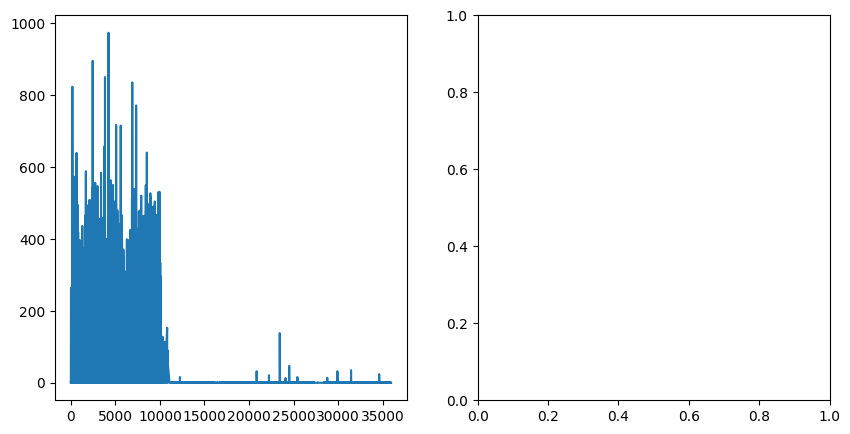

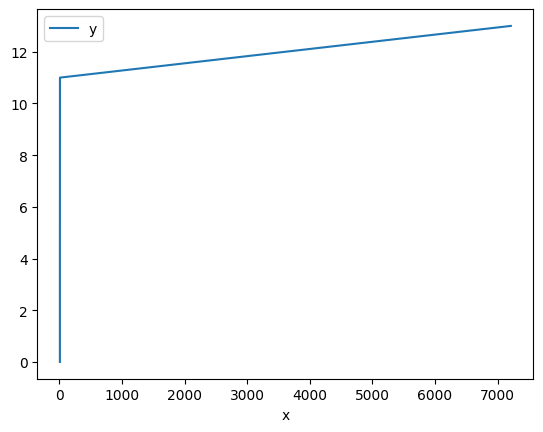

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
ticks = statement_to_df("select tick as x, micros_elapsed as y from server_ticks")
plt.plot(ticks["x"], ticks["y"])
plt.subplot(1, 2, 2)
player_counts = statement_to_df("select tick as x, count as y from player_counts")
plt.plot(player_counts["x"], player_counts["y"])
# statement_to_df("select id as x, micros as y from pings").plot("x", "y")
plt.show()

array([[<Axes: title={'center': 'y'}>]], dtype=object)

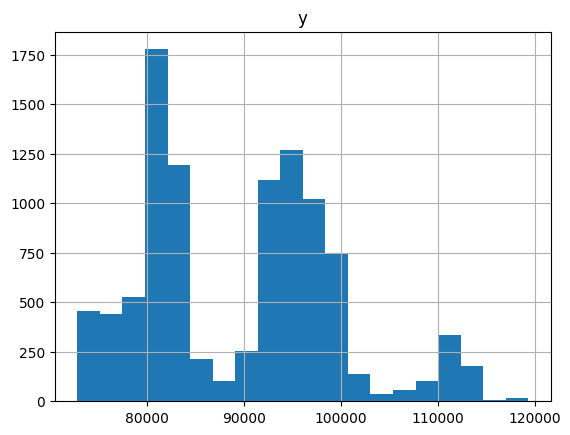

In [ ]:
df = statement_to_df("select id as x, micros as y from pings limit 10000")
df.hist(column='y', bins=20)

<Axes: xlabel='x'>

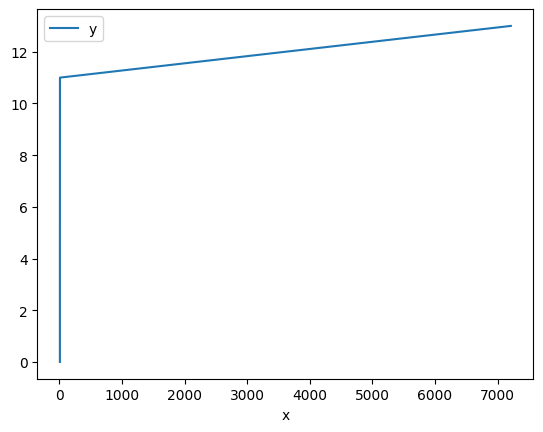